# xThreat Tutorial — SkillCorner edition


## 0. Setup


In [1]:
from pathlib import Path
import json
import os
import sys
import urllib.request as request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

DATA_SOURCE = "opendata"   # "opendata" (public 10-match sample) or "local" (your SkillCorner bundle)
LOCAL_MATCH_LIMIT = 60      # used only when DATA_SOURCE == "local"; set None for all matches
LOCAL_SKILLCORNER_ROOT = os.environ.get("SKILLCORNER_ROOT")
LOCAL_SKILLCORNER_ROOT = Path(LOCAL_SKILLCORNER_ROOT) if LOCAL_SKILLCORNER_ROOT else None
LOCAL_SEASON_NAMES = None   # e.g. ["2024"]

PITCH_X, PITCH_Y = 105.0, 68.0
L, W = 16, 12
CARRY_MIN_DISTANCE = 1.0

root = Path.cwd().resolve()
for p in [root, *root.parents]:
    if (p / "xthreat").exists() and (p / "xpass").exists():
        root = p
        break
for p in [root, root / "football-cdf"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

OPENDATA_BASE = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches"
OPENDATA_MATCH_IDS = [1886347, 1899585, 1925299, 1953632, 1996435,
                      2006229, 2011166, 2013725, 2015213, 2017461]
OPENDATA_CACHE = root / "tmp/data/skillcorner_opendata"

from xthreat.xthreat_model import (
    get_flat_indexes_center, scoring_prob, action_prob, move_transition_matrix,
)


def require_local_root() -> Path:
    if LOCAL_SKILLCORNER_ROOT is None:
        raise ValueError(
            "Set LOCAL_SKILLCORNER_ROOT or the SKILLCORNER_ROOT environment variable "
            "when DATA_SOURCE='local'."
        )
    return Path(LOCAL_SKILLCORNER_ROOT)


def new_pitch(half=False, figsize=(9.0, 6.0)):
    pitch = Pitch(pitch_type="custom", pitch_length=PITCH_X, pitch_width=PITCH_Y,
                  half=half, pitch_color="none", line_color="#3b3b3b", linewidth=1.3,
                  goal_type="box", corner_arcs=True, line_zorder=3)
    fig, ax = pitch.draw(figsize=figsize)
    return pitch, fig, ax


def show_surface(grid, title, cmap="viridis"):
    pitch, fig, ax = new_pitch(half=False, figsize=(9, 6))
    im = ax.imshow(grid, extent=[0, PITCH_X, 0, PITCH_Y], origin="lower",
                   cmap=cmap, aspect="auto", alpha=0.9, zorder=1)
    fig.colorbar(im, ax=ax, shrink=0.7, label="xT")
    ax.set_title(title)
    plt.show()


print("DATA_SOURCE =", DATA_SOURCE, "| grid", L, "x", W)


DATA_SOURCE = opendata | grid 16 x 12


## 1. Build an action table from Dynamic Events

Each `player_possession` can be decomposed into actions:

- **carry:** possession start (`x_start, y_start`) to possession end (`x_end, y_end`).
- **pass:** possession end to targeted reception or pass target; success is `pass_outcome == "successful"`.
- **shot:** possession end; goal is `game_interruption_after == "goal_for"`.

All coordinates are rescaled to a 105 x 68 m pitch.


### 1-1. Inspect one raw Dynamic Events match


In [2]:
def opendata_match(mid):
    OPENDATA_CACHE.mkdir(parents=True, exist_ok=True)
    base = f"{OPENDATA_BASE}/{mid}"
    ev_path = OPENDATA_CACHE / f"{mid}_dynamic_events.csv"; mj_path = OPENDATA_CACHE / f"{mid}_match.json"
    if not ev_path.exists():
        request.urlretrieve(f"{base}/{mid}_dynamic_events.csv", ev_path)
    if not mj_path.exists():
        request.urlretrieve(f"{base}/{mid}_match.json", mj_path)
    meta = json.load(open(mj_path))
    return pd.read_csv(ev_path, low_memory=False), float(meta["pitch_length"]), float(meta["pitch_width"])


def local_iter(limit=None):
    from xpass.skillcorner_passes import load_match_index
    from xg.skillcorner_shots import resolve_match_context
    idx = load_match_index(require_local_root(), season_names=LOCAL_SEASON_NAMES)
    if limit is not None:
        idx = idx.head(int(limit))
    for _, row in idx.iterrows():
        ctx = resolve_match_context(require_local_root(), row["match_id"], match_dir=row.get("match_dir"))
        m = ctx.match_metadata
        yield (pd.read_csv(ctx.event_path, low_memory=False),
               float(m["pitch_length"]), float(m["pitch_width"]), str(row["match_id"]))


if DATA_SOURCE == "opendata":
    ev, pl, pw = opendata_match(OPENDATA_MATCH_IDS[0]); ex_label = f"open data {OPENDATA_MATCH_IDS[0]}"
elif DATA_SOURCE == "local":
    ev, pl, pw, ex_id = next(local_iter(1)); ex_label = f"local SkillCorner {ex_id}"
else:
    raise ValueError("DATA_SOURCE must be 'opendata' or 'local'")

print(f"{ex_label}: {len(ev):,} events | pitch {pl} x {pw}")
display(ev.loc[ev["event_type"].eq("player_possession"), "end_type"].value_counts().head(8))


open data 1886347: 5,079 events | pitch 104.0 x 68.0


end_type
pass               902
possession_loss     48
shot                23
foul_suffered       15
clearance            9
unknown              2
Name: count, dtype: int64

### 1-2. Extract action rows

The carry rows follow the reusable package implementation: a `player_possession` row becomes a carry when SkillCorner marks `carry == true` or when that same row's start/end coordinates move at least 1 metre. Because `player_possession` is already player-specific, this distance check never joins two different players' actions.


In [3]:
def actions_from_events(events, pitch_length, pitch_width):
    sx, sy = PITCH_X / float(pitch_length), PITCH_Y / float(pitch_width)
    pp = events[events["event_type"].eq("player_possession")].copy()

    def numeric_col(col):
        if col not in pp.columns:
            return pd.Series(np.nan, index=pp.index)
        return pd.to_numeric(pp[col], errors="coerce")

    def bool_col(col):
        if col not in pp.columns:
            return pd.Series(False, index=pp.index, dtype=bool)
        return (pp[col].astype("string").str.lower()
                .map({"true": True, "false": False, "1": True, "0": False})
                .fillna(False).astype(bool))

    def metadata(mask):
        idx = pp.index[mask]
        cols = [
            "event_id", "index", "match_id", "frame_start", "frame_end", "time_start", "time_end",
            "minute_start", "second_start", "duration", "period", "attacking_side", "player_id",
            "player_name", "player_position", "team_id", "team_shortname", "start_type", "end_type",
            "carry", "distance_covered", "speed_avg", "trajectory_angle", "trajectory_direction",
        ]
        data = {}
        for col in cols:
            if col in pp.columns:
                data[col] = pp.loc[idx, col]
            else:
                data[col] = pd.Series(pd.NA, index=idx)
        return pd.DataFrame(data, index=idx)

    x0, y0 = numeric_col("x_start") * sx, numeric_col("y_start") * sy
    x1, y1 = numeric_col("x_end") * sx, numeric_col("y_end") * sy
    rx, ry = numeric_col("player_targeted_x_reception") * sx, numeric_col("player_targeted_y_reception") * sy
    tx, ty = numeric_col("player_targeted_x_pass") * sx, numeric_col("player_targeted_y_pass") * sy

    displacement = np.hypot(x1 - x0, y1 - y0)
    carry_flag = bool_col("carry")
    moved = x0.notna() & y0.notna() & x1.notna() & y1.notna() & displacement.ge(CARRY_MIN_DISTANCE)
    carry_mask = carry_flag | moved

    carry = metadata(carry_mask)
    carry["start_x"] = x0[carry_mask]
    carry["start_y"] = y0[carry_mask]
    carry["end_x"] = x1[carry_mask]
    carry["end_y"] = y1[carry_mask]
    carry["action_type"] = "carry"
    carry["move_success"] = True
    carry["goal"] = False
    carry["carry_flag_skillcorner"] = carry_flag[carry_mask]
    carry["carry_displacement"] = displacement[carry_mask]

    pm = pp["end_type"].eq("pass")
    pass_end_x = rx.where(rx.notna(), tx)
    pass_end_y = ry.where(ry.notna(), ty)
    passes = metadata(pm)
    passes["start_x"] = x1[pm]
    passes["start_y"] = y1[pm]
    passes["end_x"] = pass_end_x[pm]
    passes["end_y"] = pass_end_y[pm]
    passes["action_type"] = "pass"
    passes["move_success"] = pp.loc[pm, "pass_outcome"].eq("successful")
    passes["goal"] = False
    passes["carry_flag_skillcorner"] = False
    passes["carry_displacement"] = np.nan

    sm = pp["end_type"].eq("shot")
    shots = metadata(sm)
    shots["start_x"] = x1[sm]
    shots["start_y"] = y1[sm]
    shots["end_x"] = x1[sm]
    shots["end_y"] = y1[sm]
    shots["action_type"] = "shot"
    shots["move_success"] = False
    shots["goal"] = pp.loc[sm, "game_interruption_after"].eq("goal_for")
    shots["carry_flag_skillcorner"] = False
    shots["carry_displacement"] = np.nan

    out = pd.concat([carry, passes, shots], ignore_index=True)
    return out.dropna(subset=["start_x", "start_y"])

ma = actions_from_events(ev, pl, pw)
print(f"{ex_label}: actions {len(ma)} | " + ", ".join(f"{k}={v}" for k, v in ma['action_type'].value_counts().items()))
display(ma.head(6))


open data 1886347: actions 1519 | pass=902, carry=594, shot=23


,event_id,index,match_id,frame_start,frame_end,time_start,time_end,minute_start,second_start,duration,...,trajectory_direction,start_x,start_y,end_x,end_y,action_type,move_success,goal,carry_flag_skillcorner,carry_displacement
0,8_1,1,1886347,48,58,00:03.8,00:04.8,0,3,1.0,...,sideway_left,-22.524519,1.22,-22.423558,2.70,carry,True,False,False,1.483440
1,8_2,5,1886347,72,89,00:06.2,00:07.9,0,6,1.7,...,forward,-17.769231,20.17,-10.853365,24.18,carry,True,False,True,7.994329
2,8_3,14,1886347,202,229,00:19.2,00:21.9,0,19,2.7,...,sideway_left,-28.107692,6.40,-23.271635,13.87,carry,True,False,True,8.898784
3,8_5,24,1886347,283,299,00:27.3,00:28.9,0,27,1.6,...,backward,-28.814423,-24.91,-38.183654,-28.89,carry,True,False,True,10.179533
4,8_6,31,1886347,301,337,00:29.1,00:32.7,0,29,3.6,...,backward,37.335577,29.90,35.144712,27.85,carry,True,False,True,3.000398
5,8_8,42,1886347,387,430,00:37.7,00:42.0,0,37,4.3,...,forward,-47.754808,-2.23,-42.686538,-0.41,carry,True,False,True,5.385142


### 1-3. Expand to all matches


In [4]:
if DATA_SOURCE == "opendata":
    frames = []
    for mid in OPENDATA_MATCH_IDS:
        ev_i, pl_i, pw_i = opendata_match(mid)
        a = actions_from_events(ev_i, pl_i, pw_i); a["match_id"] = str(mid)
        frames.append(a)
    actions = pd.concat(frames, ignore_index=True)
else:
    frames = []
    for ev_i, pl_i, pw_i, mid in local_iter(LOCAL_MATCH_LIMIT):
        a = actions_from_events(ev_i, pl_i, pw_i); a["match_id"] = mid
        frames.append(a)
    actions = pd.concat(frames, ignore_index=True)

for c in ["start_x", "start_y", "end_x", "end_y"]:
    actions[c] = pd.to_numeric(actions[c], errors="coerce")
actions["move_success"] = actions["move_success"].fillna(False).astype(bool)
actions["goal"] = actions["goal"].fillna(False).astype(bool)
print(f"{len(actions):,} actions | matches {actions['match_id'].nunique()}")
print("by type:", actions["action_type"].value_counts().to_dict())
print("shots:", int(actions['action_type'].eq('shot').sum()), "| goals:", int(actions['goal'].sum()))


14,366 actions | matches 10
by type: {'pass': 8585, 'carry': 5555, 'shot': 226}
shots: 226 | goals: 26


## 2. Intuition — per-cell probabilities

Before solving for xT, inspect the ingredients: the probability of shooting from each cell and the probability of scoring given a shot from that cell.


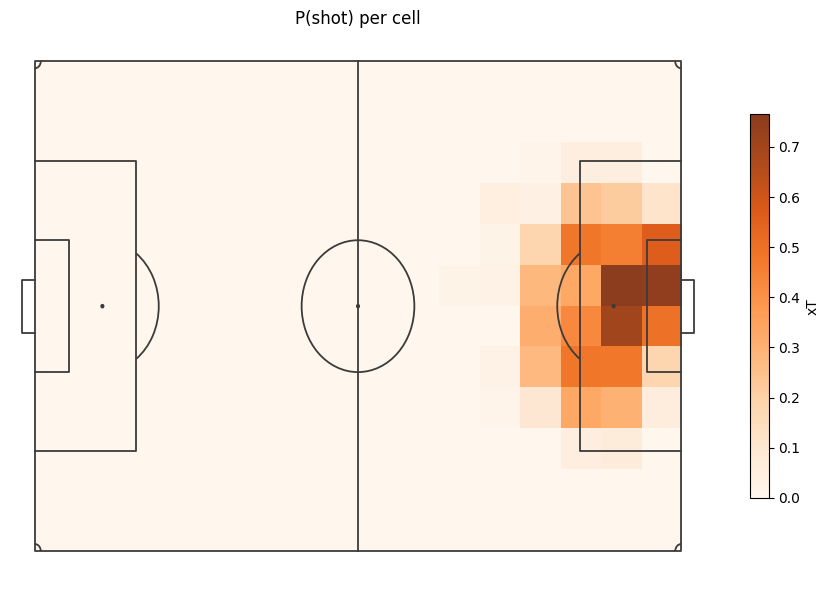

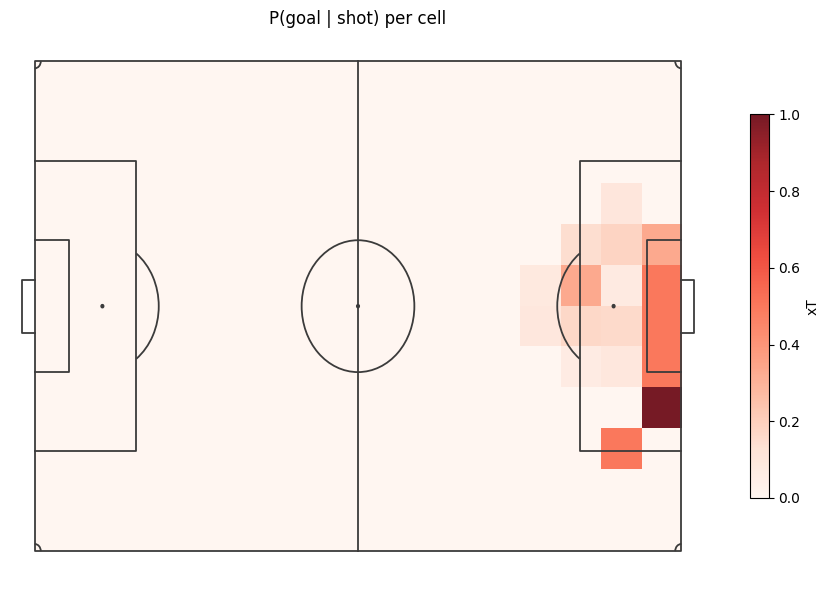

In [5]:
shot_prob, move_prob = action_prob(actions, l=L, w=W)   # P(shot from cell), P(move from cell)
goal_prob = scoring_prob(actions, l=L, w=W)             # P(goal | shot from cell)
show_surface(shot_prob, "P(shot) per cell", cmap="Oranges")
show_surface(goal_prob, "P(goal | shot) per cell", cmap="Reds")

## 3. Learn the xT grid with value iteration

For every grid cell, iterate until convergence:

```text
xT(cell) = P(shot) * P(goal | shot)
         + P(move) * sum_over_destinations(T(cell -> destination) * xT(destination))
```

`T` is the transition matrix for successful moves.


converged in 42 iterations (final delta 8.98e-06)


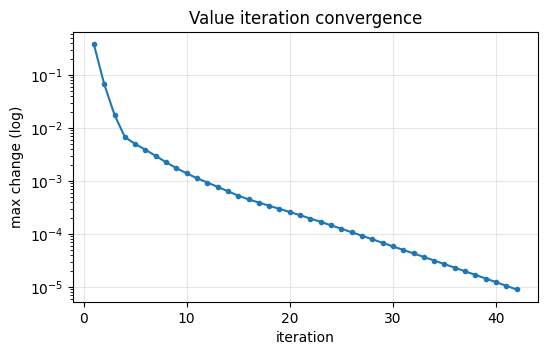

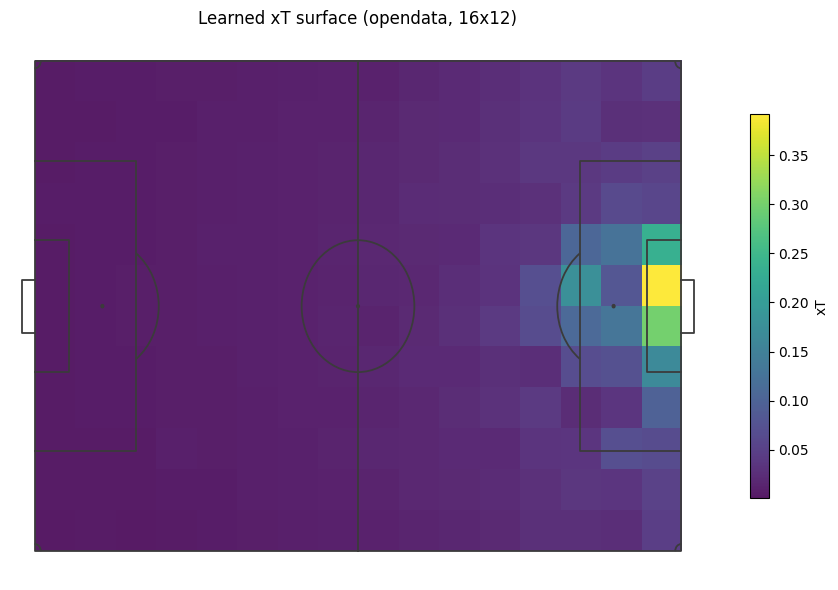

In [6]:
T = move_transition_matrix(actions, l=L, w=W)
immediate = (shot_prob * goal_prob).reshape(-1)
flat_move = move_prob.reshape(-1)

xt = np.zeros(L * W, dtype=float)
deltas = []
for _ in range(200):
    new = immediate + flat_move * (T @ xt)
    delta = np.abs(new - xt).max()
    xt = new
    deltas.append(delta)
    if delta < 1e-5:
        break
xT = xt.reshape(W, L)
print(f"converged in {len(deltas)} iterations (final delta {deltas[-1]:.2e})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(deltas) + 1), deltas, marker="o", ms=3)
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("max change (log)")
ax.set_title("Value iteration convergence"); ax.grid(alpha=.3); plt.show()

show_surface(xT, f"Learned xT surface ({DATA_SOURCE}, {L}x{W})")


## 4. Score actions — who created threat?

For every successful pass or carry, compute `xT(destination) - xT(origin)`. Aggregating those values by player shows who created the most threat.


players with >= 50 successful moves: 95


,player_name,moves,xt_total,xt_per_100
113,L. Gillion,111,0.901,0.811
58,F. De Vries,184,0.879,0.478
5,A. Cáceres,183,0.768,0.420
2,A. Behich,191,0.700,0.367
123,Léo Sena,132,0.671,0.508
179,S. Sutton,117,0.634,0.542
144,N. Atkinson,159,0.583,0.367
42,D. Arzani,88,0.577,0.655
69,H. Sakai,159,0.573,0.360
59,F. Gallegos,213,0.486,0.228


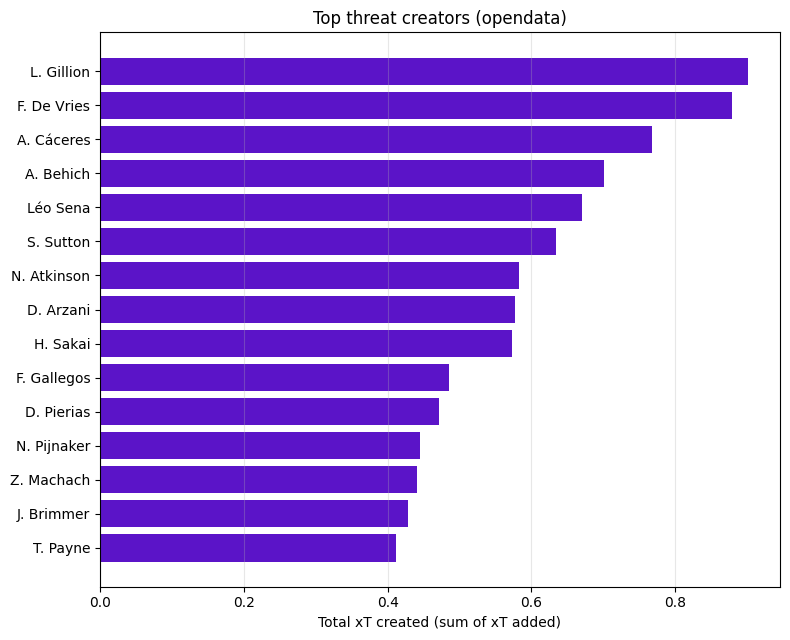

In [7]:
flat_xt = xT.reshape(-1)
moves = actions[actions["action_type"].isin(["pass", "carry"]) & actions["move_success"]].copy()
moves = moves.dropna(subset=["start_x", "start_y", "end_x", "end_y"])
start_idx = get_flat_indexes_center(moves["start_x"], moves["start_y"], l=L, w=W).to_numpy().astype(int)
end_idx = get_flat_indexes_center(moves["end_x"], moves["end_y"], l=L, w=W).to_numpy().astype(int)
moves["xt_added"] = flat_xt[end_idx] - flat_xt[start_idx]
moves["custom_xT_added"] = moves["xt_added"]

min_actions = 200 if DATA_SOURCE == "local" else 50
name_col = "player_name" if "player_name" in moves.columns else "team_id"
players = (moves.groupby(name_col, dropna=False)
                .agg(moves=("xt_added", "size"), xt_total=("xt_added", "sum"),
                     xt_per_100=("xt_added", lambda s: s.mean() * 100))
                .reset_index())
players = players[players["moves"] >= min_actions].sort_values("xt_total", ascending=False)
print(f"players with >= {min_actions} successful moves: {len(players)}")
top = players.head(15)
display(top.round(3))

if len(top):
    fig, ax = plt.subplots(figsize=(8, 6.5))
    o = top.iloc[::-1]
    ax.barh(o[name_col].astype(str), o["xt_total"], color="#5B14C8")
    ax.set_xlabel("Total xT created (sum of xT added)")
    ax.set_title(f"Top threat creators ({DATA_SOURCE})"); ax.grid(axis="x", alpha=.3)
    fig.tight_layout(); plt.show()


### 4-1. Pass xT vs carry xT

Total xT can come from passes, carries, or both. Split successful move value by action type and by route channel to see whether threat creation is pass-driven, carry-driven, central, half-space, or wide.


,action_type,moves,xt_total,positive_xt,xt_per_100
1,pass,6771,15.866,27.703,0.234
0,carry,5555,7.417,14.410,0.134


,route_channel,action_type,moves,xt_total,positive_xt,xt_per_100
1,central,pass,2230,7.699,11.956,0.345
3,half-space,pass,2448,5.934,10.078,0.242
2,half-space,carry,1929,3.604,5.817,0.187
5,wide,pass,2093,2.234,5.669,0.107
4,wide,carry,1984,2.048,3.968,0.103
0,central,carry,1642,1.765,4.626,0.108


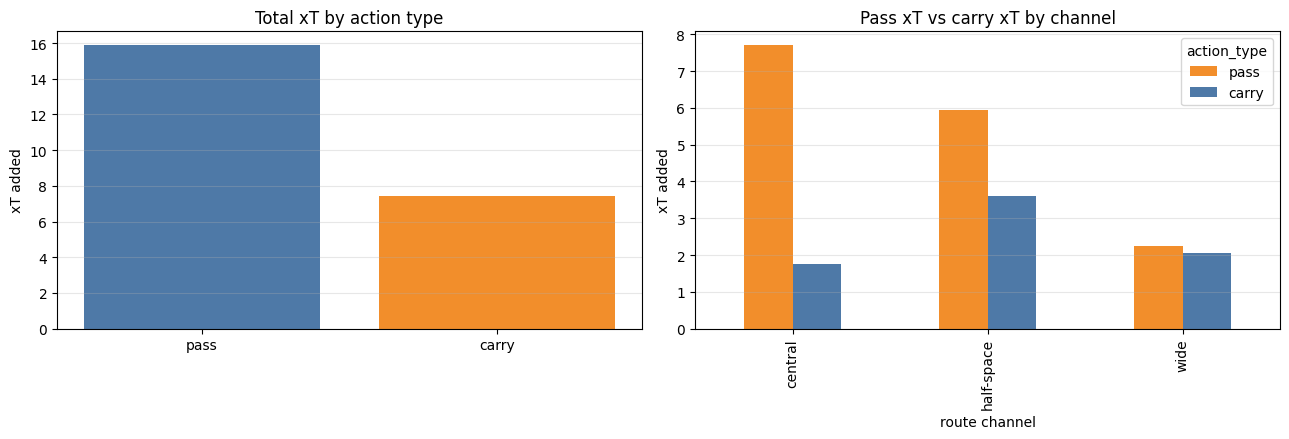

In [8]:
from xthreat.xthreat_plots import add_route_columns, ACTION_COLORS, CHANNEL_COLORS

moves_detail = add_route_columns(moves)
moves_detail["positive_xt"] = moves_detail["xt_added"].clip(lower=0)

by_action = (moves_detail.groupby("action_type")
             .agg(moves=("xt_added", "size"),
                  xt_total=("xt_added", "sum"),
                  positive_xt=("positive_xt", "sum"),
                  xt_per_100=("xt_added", lambda s: s.mean() * 100))
             .reset_index()
             .sort_values("xt_total", ascending=False))
display(by_action.round(3))

route_summary = (moves_detail.groupby(["route_channel", "action_type"])
                 .agg(moves=("xt_added", "size"),
                      xt_total=("xt_added", "sum"),
                      positive_xt=("positive_xt", "sum"),
                      xt_per_100=("xt_added", lambda s: s.mean() * 100))
                 .reset_index())
display(route_summary.sort_values("xt_total", ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
action_plot = by_action.set_index("action_type").reindex(["pass", "carry"]).dropna(how="all")
axes[0].bar(action_plot.index.astype(str), action_plot["xt_total"],
            color=[ACTION_COLORS.get(a, "#777777") for a in action_plot.index])
axes[0].set_title("Total xT by action type")
axes[0].set_ylabel("xT added")
axes[0].grid(axis="y", alpha=.3)

pivot = route_summary.pivot_table(index="route_channel", columns="action_type", values="xt_total", aggfunc="sum", fill_value=0.0)
pivot = pivot.reindex([c for c in ["central", "half-space", "wide", "unknown"] if c in pivot.index])
pivot[[c for c in ["pass", "carry"] if c in pivot.columns]].plot(
    kind="bar", ax=axes[1], color=[ACTION_COLORS.get(c, "#777777") for c in pivot.columns if c in ["pass", "carry"]]
)
axes[1].set_title("Pass xT vs carry xT by channel")
axes[1].set_xlabel("route channel")
axes[1].set_ylabel("xT added")
axes[1].grid(axis="y", alpha=.3)
fig.tight_layout(); plt.show()


### 4-2. How did the top xT creator generate threat?

After identifying the highest-total xT player, inspect whether their value came more from passes or carries, which channels they used, and the highest-value routes they created.


,player_name,moves,xt_total,positive_xt
113,L. Gillion,111,0.901,1.183
58,F. De Vries,184,0.879,1.146
5,A. Cáceres,183,0.768,1.166
2,A. Behich,191,0.700,0.953
123,Léo Sena,132,0.671,0.767
179,S. Sutton,117,0.634,0.768
144,N. Atkinson,159,0.583,0.798
42,D. Arzani,88,0.577,0.825
69,H. Sakai,159,0.573,0.709
59,F. Gallegos,213,0.486,0.789


action_type,carry,pass,total
player_name,,,
L. Gillion,0.238,0.662,0.901
F. De Vries,0.025,0.854,0.879
A. Cáceres,0.188,0.581,0.768
J. Randall,0.265,0.481,0.746
A. Behich,0.367,0.334,0.700
Léo Sena,0.070,0.600,0.671
S. Sutton,0.043,0.591,0.634
N. Atkinson,0.036,0.548,0.583
D. Arzani,0.364,0.213,0.577


,player_name,action_type,route_channel,start_x,start_y,end_x,end_y,xt_added,match_id
1272,L. Gillion,pass,central,48.865,14.78,45.988,0.93,0.335,1886347
1260,L. Gillion,pass,central,47.432,7.96,46.775,3.22,0.158,1886347
1648,L. Gillion,carry,central,32.217,2.39,33.822,1.94,0.107,1899585
2539,L. Gillion,pass,central,47.391,17.55,44.736,-4.65,0.081,1899585
2157,L. Gillion,pass,central,20.041,11.47,29.067,0.14,0.045,1899585
2464,L. Gillion,pass,central,30.359,15.39,32.500,2.96,0.042,1899585
414,L. Gillion,carry,central,26.825,18.32,29.794,3.68,0.033,1886347
1841,L. Gillion,carry,half-space,28.612,29.22,39.526,11.93,0.029,1899585
372,L. Gillion,carry,half-space,35.387,21.43,39.688,16.15,0.024,1886347
320,L. Gillion,carry,half-space,4.775,20.10,37.992,11.54,0.023,1886347


,route_channel,action_type,moves,xt_total,positive_xt
1,central,pass,16,0.648,0.669
2,half-space,carry,30,0.116,0.160
0,central,carry,9,0.071,0.154
4,wide,carry,22,0.051,0.089
3,half-space,pass,19,0.023,0.055
5,wide,pass,15,-0.009,0.057


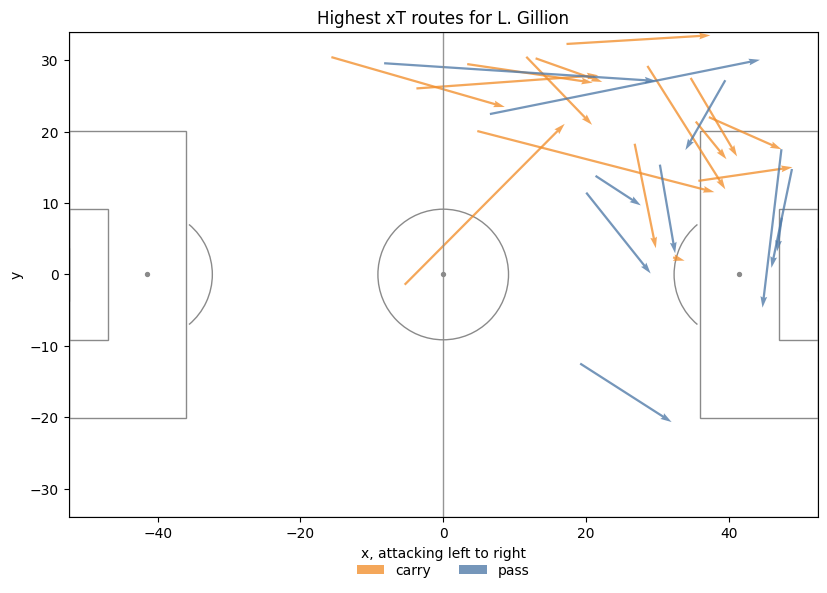

In [9]:
from xthreat.xthreat_plots import draw_center_origin_pitch

player_action = (moves_detail.groupby([name_col, "action_type"], dropna=False)
                 .agg(moves=("xt_added", "size"),
                      xt_total=("xt_added", "sum"),
                      positive_xt=("positive_xt", "sum"),
                      xt_per_100=("xt_added", lambda s: s.mean() * 100))
                 .reset_index())

player_totals = (player_action.groupby(name_col, dropna=False)
                 .agg(moves=("moves", "sum"), xt_total=("xt_total", "sum"), positive_xt=("positive_xt", "sum"))
                 .reset_index())
player_totals = player_totals[player_totals["moves"] >= min_actions].sort_values("xt_total", ascending=False)
display(player_totals.head(10).round(3))

mix = player_action.pivot_table(index=name_col, columns="action_type", values="xt_total", aggfunc="sum", fill_value=0.0)
mix["total"] = mix.sum(axis=1)
mix = mix.sort_values("total", ascending=False)
display(mix.head(10).round(3))

if player_totals.empty:
    print("No player met the minimum-action threshold. Lower min_actions for a smaller sample.")
else:
    top_creator = player_totals.iloc[0][name_col]
    focus = moves_detail[moves_detail[name_col].astype(str).eq(str(top_creator))].copy()
    focus_top = focus.sort_values("xt_added", ascending=False).head(25)
    cols = [name_col, "action_type", "route_channel", "start_x", "start_y", "end_x", "end_y", "xt_added", "match_id"]
    display(focus_top[[c for c in cols if c in focus_top.columns]].round(3))

    focus_route = (focus.groupby(["route_channel", "action_type"])
                   .agg(moves=("xt_added", "size"), xt_total=("xt_added", "sum"),
                        positive_xt=("positive_xt", "sum"))
                   .reset_index()
                   .sort_values("xt_total", ascending=False))
    display(focus_route.round(3))

    fig, ax = plt.subplots(figsize=(10, 6))
    draw_center_origin_pitch(ax, line_color="#8a8a8a", linewidth=1.0)
    for action_type, frame in focus_top.groupby("action_type"):
        ax.quiver(frame["start_x"], frame["start_y"],
                  frame["end_x"] - frame["start_x"], frame["end_y"] - frame["start_y"],
                  angles="xy", scale_units="xy", scale=1,
                  color=ACTION_COLORS.get(action_type, "#777777"),
                  width=0.003, alpha=0.78, label=action_type)
    ax.set_title(f"Highest xT routes for {top_creator}")
    ax.set_xlabel("x, attacking left to right")
    ax.set_ylabel("y")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
    fig.tight_layout(); plt.show()
